In [15]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [16]:
class State(TypedDict):
    # Messagee have type of `list` The `add_messages` function
    # in the annotation define how this state key should be updated 
    # (in this class it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [17]:
import os 
from dotenv import load_dotenv

load_dotenv()




True

In [18]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama3-8b-8192"
)

In [19]:
# Node Functionality 
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


In [20]:
# Adding Nodes 
graph_builder.add_node('chatbot', chatbot)

# Adding Edges 
graph_builder.add_edge(START, 'chatbot')
graph_builder.add_edge('chatbot', END)


In [21]:
graph = graph_builder.compile()

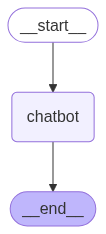

In [22]:
# Visualizing the Graph 
from IPython.display import Image, display

graph.get_graph().draw_mermaid_png()

display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
response = graph.invoke({"messages": "Buss message karne ka mnn tha"})

In [24]:
response['messages'][-1].content

'I think I understand what you\'re trying to say!\n\n"Buss message karne ka mann tha" is a Hindi phrase, and it translates to "The mind was willing to send a message" or "I was willing to send a message".\n\nIs that correct?'

In [25]:
for event in graph.stream({"messages": "Buss message karne ka mnn tha"}):
    for value in event.values():
        print(value['messages'][-1].content)

It seems like you're trying to say "Maine buss message karna chahta tha" which translates to "I wanted to send a WhatsApp message". Is that correct?


### ChatBot With Tools

In [26]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)





In [27]:
from langchain_core.tools import Tool

def multiply_fn(a: int, b: int) -> int:
    return a * b

multiply = Tool(
    name="multiply",
    func=multiply_fn,
    description="Multiplies two numbers"
)


In [28]:
tools = [tool, multiply]

In [29]:
llm_with_tool = llm.bind_tools(tools )

In [30]:
llm_with_tool

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x10f780c90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10f80a410>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domains to 

In [31]:
## Sategraph 
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [32]:
## Node Definition
def tool_calling_llm(state: State): 
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


# Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_node("tools", ToolNode(tools))

# Add Edges 
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm', 
    # if the latest messages (result) from assistant is a tool call -> tools_condition routes to tool 
    # if the latest messages (result) from assistant is a not a tool call -> tool_condition routes to end
    tools_condition
)
builder.add_edge('tools', END)

## Compile the graph 
graph = builder.compile()

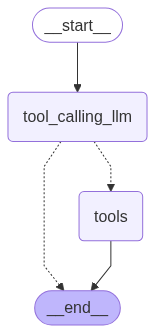

In [33]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
res = graph.invoke({'messages':"what is recent ai new"})

In [35]:
res['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newsweek.com/nw-ai/ai-impact-awards-2025-science-engineering-2084754", "title": "AI Impact Awards 2025: The Changing Human Role in Science and Engineering - Newsweek", "score": 0.7251239, "published_date": "Wed, 25 Jun 2025 10:02:01 GMT", "content": "Newsweek _\\\\_will continue the conversation on meaningful AI innovations at our AI Impact Summit from June 23 to 25 in Sonoma, California. Click here to follow along on the live blog.\\\\__\\n\\nRequest Reprint & LicensingSubmit CorrectionView Editorial Guidelines\\n\\nSHARE:xfacebooklinkedinredditemailwhatsappCopy & Share\\n\\n✓ Link copied to clipboard!\\n\\nThe Latest in AI\\n----------------\\n\\nNEWSWEEK.AI\\n\\n06.09.25\\n\\n### Generative AI\'s Mission to Explore Strange New Worlds [...] ### AI Will Connect Mercedes-Benz Places Residents to the World\\n\\nThe new Miami condo complex will have state-of-the-art te

In [36]:
res = graph.invoke({'messages':"what is recent ai new"})
for m in res['messages']:
    m.pretty_print()

================================ Human Message =================================

what is recent ai new
================================== Ai Message ==================================
Tool Calls:
  tavily_search (7bnjtmeeq)
 Call ID: 7bnjtmeeq
  Args:
    query: recent AI news
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.newsweek.com/nw-ai/ai-impact-awards-2025-science-engineering-2084754", "title": "AI Impact Awards 2025: The Changing Human Role in Science and Engineering - Newsweek", "score": 0.7251239, "published_date": "Wed, 25 Jun 2025 10:02:01 GMT", "content": "Newsweek _\\_will continue the conversation on meaningful AI innovations at our AI Impact Summit from June 23 to 25 in Sonoma, California. Click here to follow along on the live blog.\\__\n\nRequest Reprin

## ReActive


In [37]:
from dotenv import load_dotenv
load_dotenv()

True

In [38]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

In [39]:
from langchain_core.tools import Tool

def multiply_fn(a: int, b: int) -> int:
    return a * b

multiply = Tool(
    name="multiply",
    func=multiply_fn,
    description="Multiplies two numbers"
)


In [42]:

## Sategraph 
tools = [tool, multiply]
llm_with_tool = llm.bind_tools(tools )

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

from typing import TypedDict, List, Dict, Any

class State(TypedDict):
    messages: List[Dict[str, Any]]


## Node Definition
def tool_calling_llm(state: State): 
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


# Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_node("tools", ToolNode(tools))

# Add Edges 
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm', 
    # if the latest messages (result) from assistant is a tool call -> tools_condition routes to tool 
    # if the latest messages (result) from assistant is a not a tool call -> tool_condition routes to end
    tools_condition
)
builder.add_edge('tools', 'tool_calling_llm')

## Compile the graph 
graph = builder.compile()

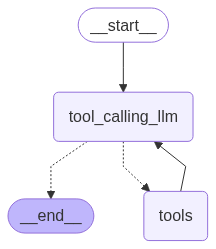

In [43]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Memory

In [45]:
res = graph.invoke({'messages': "Hello my name is Mausham"})
for i in res['messages']:
    i.pretty_print()

================================== Ai Message ==================================

<p>Hi Mausham! Nice to meet you. What brings you here today?</p>


In [46]:
res = graph.invoke({'messages':"My name is Mausham"})
for m in res['messages']:
    m.pretty_print()

================================== Ai Message ==================================

Nice to meet you, Mausham! I'm here to assist you with any questions or topics you'd like to discuss. Please feel free to ask me anything, and I'll do my best to provide helpful and accurate information.


In [47]:
from langgraph.checkpoint.memory import MemorySaver

In [48]:
memory = MemorySaver()

In [49]:

## Sategraph 
tools = [tool, multiply]
llm_with_tool = llm.bind_tools(tools )

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

from typing import TypedDict, List, Dict, Any

class State(TypedDict):
    messages: List[Dict[str, Any]]


## Node Definition
def tool_calling_llm(state: State): 
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


# Graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)

builder.add_node("tools", ToolNode(tools))

# Add Edges 
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
    'tool_calling_llm', 
    # if the latest messages (result) from assistant is a tool call -> tools_condition routes to tool 
    # if the latest messages (result) from assistant is a not a tool call -> tool_condition routes to end
    tools_condition
)
builder.add_edge('tools', 'tool_calling_llm')

## Compile the graph 
graph = builder.compile(checkpointer=memory)

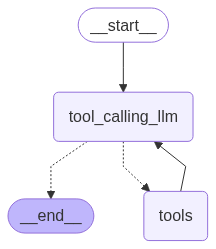

In [50]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [56]:
config={'configurable':{'thread_id':"1"}}


In [60]:
res = graph.invoke({'messages':"My name is Mausham"}, config=config)
res['messages'][-1].content

'Nice to meet you, Mausham!'

In [61]:
res = graph.invoke({'messages':"What is my name"}, config=config)
res['messages'][-1].content

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<tool-use>\n{\n  "tool_calls": [\n    {\n      "id": "pending",\n      "type": "function",\n      "function": {\n        "name": "multiply"\n      },\n      "parameters": {\n        "__arg1": 2,\n        "__arg2": 3\n      }\n    }\n  ]\n}\n</tool-use>'}}